In [29]:
from absl import logging
from flax import linen as nn
from flax.training import train_state
import jax
import jax.numpy as jnp
import numpy as np
import optax
# import tensorflow_datasets as tfds # I don't like tensorflow 
from datasets import load_dataset


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [30]:
from matplotlib import pyplot as plt
from typing import Sequence

In [31]:
class CNN(nn.Module):
  """A simple CNN model."""

  @nn.compact
  def __call__(self, x):
    x = nn.Conv(features=32, kernel_size=(3, 3))(x)
    x = nn.relu(x)
    x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
    x = nn.Conv(features=64, kernel_size=(3, 3))(x)
    x = nn.relu(x)
    x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
    x = x.reshape((x.shape[0], -1))  # flatten
    x = nn.Dense(features=256)(x)
    x = nn.relu(x)
    x = nn.Dense(features=10)(x)
    return x

class ConvBlock(nn.Module):
    """A convolutional block consisting of a convolutional layer followed by ReLU and average pooling."""
    features: int

    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=self.features, kernel_size=(3, 3))(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
        return x

class Classifier(nn.Module):
    features: int

    @nn.compact
    def __call__(self, x):
        x = x.reshape((x.shape[0], -1))  # flatten
        
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=10)(x)

        return x

class CNN(nn.Module):
    """A deeper CNN model with modular convolutional blocks."""
    features: Sequence[int]
    
    def setup(self):
        layers = []
        for _, dim in enumerate(self.features):
            layers.append(
                ConvBlock(features=dim)
            )
        layers.append(Classifier(features=128))
        self.layers = tuple(layers)

    def __call__(self, x):
        self.sow('intermediates', f'layer_{0}_output', x)
        for i, layer in enumerate(self.layers):
            x = self.perturb(f'layer_{i+1}', x)
            x = layer(x)
            self.sow('intermediates', f'layer_{i+1}_output', x)

        return x

In [66]:
import jax.numpy as jnp
from flax import linen as nn

class PatchEmbedding(nn.Module):
    patch_size: int
    num_patches: int
    embed_dim: int

    @nn.compact
    def __call__(self, x):
        # Reshape input into patches
        batch_size, height, width, channels = x.shape
        assert height % self.patch_size == 0 and width % self.patch_size == 0, "Image size must be divisible by patch size"
        x = x.reshape(batch_size, height // self.patch_size, self.patch_size, width // self.patch_size, self.patch_size, channels)
        x = x.transpose(0, 1, 3, 2, 4, 5).reshape(batch_size, self.num_patches, -1)  # Flatten patches
        # Linear projection to embedding dimension
        x = nn.Dense(self.embed_dim)(x)
        return x

class TransformerBlock(nn.Module):
    embed_dim: int
    num_heads: int
    mlp_dim: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, deterministic: bool = True):
        # Multi-head self-attention
        x = x + nn.MultiHeadDotProductAttention(num_heads=self.num_heads, qkv_features=self.embed_dim, dropout_rate=self.dropout_rate)(x, x, deterministic=deterministic)
        # Layer normalization
        x = nn.LayerNorm()(x)
        # MLP block
        residual = x
        x = nn.Dense(self.mlp_dim)(x)
        x = nn.gelu(x)
        x = nn.Dense(self.embed_dim)(x)
        x = nn.Dropout(rate=self.dropout_rate)(x, deterministic=deterministic)
        x = residual + x
        # Layer normalization
        x = nn.LayerNorm()(x)
        return x

class VisionTransformer(nn.Module):
    image_size: int
    patch_size: int
    embed_dim: int
    num_heads: int
    mlp_dim: int
    num_layers: int
    num_classes: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, deterministic: bool = True):
        # Compute number of patches
        num_patches = (self.image_size // self.patch_size) ** 2
        # Patch embedding
        x = PatchEmbedding(patch_size=self.patch_size, num_patches=num_patches, embed_dim=self.embed_dim)(x)
        # Add class token
        class_token = self.param('class_token', nn.initializers.normal(stddev=0.02), (1, 1, self.embed_dim))
        class_token = jnp.tile(class_token, (x.shape[0], 1, 1))  # Repeat for batch size
        x = jnp.concatenate([class_token, x], axis=1)  # Prepend class token
        # Add positional encoding
        pos_encoding = self.param('pos_encoding', nn.initializers.normal(stddev=0.02), (1, num_patches + 1, self.embed_dim))
        x = x + pos_encoding
        
        # Transformer blocks
        print(x.shape)
        for _ in range(self.num_layers):
            x = TransformerBlock(embed_dim=self.embed_dim, num_heads=self.num_heads, mlp_dim=self.mlp_dim, dropout_rate=self.dropout_rate)(x, deterministic=deterministic)

            
        # Classification head (use class token)
        x = x[:, 0]  # Extract class token
        x = nn.Dense(self.num_classes)(x)
        return x

In [19]:
def get_datasets():
    """Load MNIST train and test datasets into memory."""
    # Load the MNIST dataset
    dataset = load_dataset('mnist')

    # Convert datasets to numpy arrays
    train_ds = {
        'image': jnp.array(dataset['train']['image']),
        'label': jnp.array(dataset['train']['label'])
    }
    test_ds = {
        'image': jnp.array(dataset['test']['image']),
        'label': jnp.array(dataset['test']['label'])
    }

    # Normalize the images
    train_ds['image'] = train_ds['image'].astype(jnp.float32) / 255.0
    test_ds['image'] = test_ds['image'].astype(jnp.float32) / 255.0

    # Reshape to mimic 3D
    train_ds['image'] = jnp.expand_dims(train_ds['image'], axis=-1)
    test_ds['image'] = jnp.expand_dims(test_ds['image'], axis=-1)


    return train_ds, test_ds

In [20]:
# Get datasets as dict of JAX arrays.
train_ds, test_ds = get_datasets()

In [21]:
def show_img(img, ax=None, title=None):
  """Shows a single image."""
  if ax is None:
    ax = plt.gca()
  ax.imshow(img[..., 0], cmap='gray')
  ax.set_xticks([])
  ax.set_yticks([])
  if title:
    ax.set_title(title)

def show_img_grid(imgs, titles):
  """Shows a grid of images."""
  n = int(np.ceil(len(imgs)**.5))
  _, axs = plt.subplots(n, n, figsize=(3 * n, 3 * n))
  for i, (img, title) in enumerate(zip(imgs, titles)):
    show_img(img, axs[i // n][i % n], title)

    

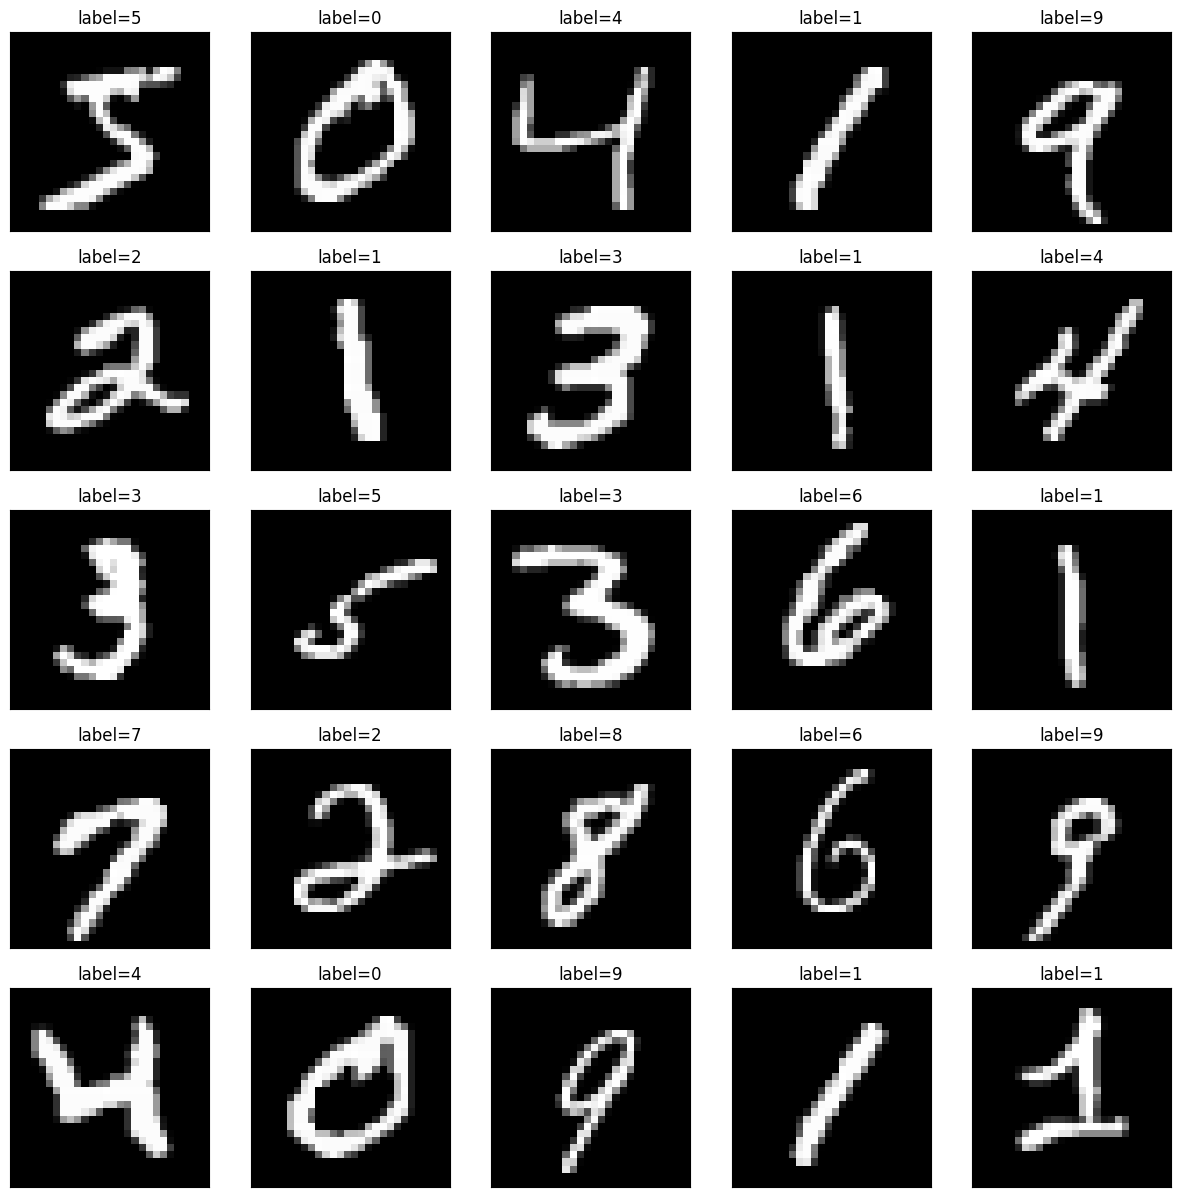

In [22]:
show_img_grid(
    [train_ds['image'][idx] for idx in range(25)],
    [f'label={train_ds["label"][idx]}' for idx in range(25)],
)

In [68]:
def create_train_state(rng):
    """Creates iynitial `TrainState`."""
    # cnn = CNN([32, 32, 64, 64])
    cnn = VisionTransformer(
        image_size=28, patch_size=7, 
        embed_dim=64, 
        num_heads=4, 
        mlp_dim=128, num_layers=4, num_classes=10, dropout_rate=0.1
    )
    params = cnn.init(rng, jnp.ones([1, 28, 28, 1]))['params']
    # tx = optax.sgd(.1, 0.9)
    tx = optax.adam(1e-4)
    return train_state.TrainState.create(apply_fn=cnn.apply, params=params, tx=tx)
@jax.jit
def apply_model(state, images, labels):
    """Computes gradients, loss and accuracy for a single batch."""
    
    def loss_fn(params):
        logits = state.apply_fn({'params': params}, images)
        one_hot = jax.nn.one_hot(labels, 10)
        loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
        return loss, logits
    
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(state.params)
    accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
    return grads, loss, accuracy


@jax.jit
def update_model(state, grads):
    return state.apply_gradients(grads=grads)

In [69]:
from tqdm.notebook import tqdm

In [71]:
def train_epoch(state, train_ds, batch_size, rng):
    """Train for a single epoch."""
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // batch_size
    
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * batch_size]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, batch_size))
    
    epoch_loss = []
    epoch_accuracy = []
    
    for perm in tqdm(perms):
        batch_images = train_ds['image'][perm, ...]
        batch_labels = train_ds['label'][perm, ...]
        grads, loss, accuracy = apply_model(state, batch_images, batch_labels)
        state = update_model(state, grads)
        epoch_loss.append(loss)
        epoch_accuracy.append(accuracy)
        train_loss = np.mean(epoch_loss)
        train_accuracy = np.mean(epoch_accuracy)
                                
    return state, train_loss, train_accuracy


rng = jax.random.key(0)
rng, init_rng = jax.random.split(rng)
state = create_train_state(init_rng)

for epoch in range(1, 11):
    print(f'Epoch {epoch}')
    rng, input_rng = jax.random.split(rng)
    state, train_loss, train_accuracy = train_epoch(
        state, train_ds, 64, input_rng
    )
    print(train_loss, train_accuracy)


(1, 17, 64)
Epoch 1


  0%|          | 0/937 [00:00<?, ?it/s]

(64, 17, 64)
0.9361153 0.69048494
Epoch 2


  0%|          | 0/937 [00:00<?, ?it/s]

0.39888906 0.87700105
Epoch 3


...

0.1100478 0.9664821
Epoch 9


  0%|          | 0/937 [00:00<?, ?it/s]

0.09781013 0.9696838
Epoch 10


  0%|          | 0/937 [00:00<?, ?it/s]

0.08434881 0.9743363


In [58]:
# model = CNN()
model =  VisionTransformer(
        image_size=28, patch_size=7, 
        embed_dim=64, 
        num_heads=4, 
        mlp_dim=128, num_layers=4, num_classes=10, dropout_rate=0.1
    )

params = model.init(rng, jnp.ones([1, 28, 28, 1]))['params']
print(sum(x.size for x in jax.tree.leaves(params)))


138890


In [65]:
params['TransformerBlock_0']['MultiHeadDotProductAttention_0']['query']['kernel'].shape

(64, 4, 16)

In [14]:
model.apply({'params': params}, train_ds['image'][0:1])

Array([[-0.02585189, -0.05415018, -0.02109532, -0.00060657, -0.0012566 ,
        -0.01025131,  0.02098311,  0.03212908, -0.04397408, -0.0056426 ]],      dtype=float32)

In [94]:
jacobian = jax.jacobian(
    model.apply,
    argnums=0,
)({'params': params}, train_ds['image'][0:1])

In [98]:
flat, _ = jax.tree.flatten(jacobian)

In [105]:
J = jnp.concat([leaf.flatten() for leaf in flat])


In [109]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

824458
